# “This is a Logistic Regression implementation from scratch, without using sklearn.
# It uses the sigmoid function, binary cross-entropy (log loss), and gradient descent to learn the parameters and  make predictions.”

# logistic Regression has 5 core ingridients
1. Linear Model
   # z= mX+c
2. Sigmoid Function
   # y_pred = sigmoid(z)
3. Binary Labels (0/1)
   # y = np.where(salary >= threshold, 1, 0)
4. Loss Function (Log Loss)
   # loss = - (y log(y_pred) + (1-y) log(1-y_pred))
5. Optimization (Gradient Descent)
      #  m = m - lr * dm
      #  c = c - lr * dc

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [25]:
data=pd.read_csv("./Data/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
data.shape

(768, 9)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [29]:
# Checking for the null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [30]:
# Checking For the Zeroes
(data==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [31]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for c in cols:
    print(c, (data[c] == 0).sum())

for c in cols:
    data[c] = data[c].replace(0, data[c].median())    # by doing we replaced all the zeroes with the median only for the important Columnns which we need in the dataset
    


Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [32]:
data["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [33]:
data.corr()["Outcome"].sort_values()


Insulin                     0.148457
BloodPressure               0.165723
DiabetesPedigreeFunction    0.173844
SkinThickness               0.189065
Pregnancies                 0.221898
Age                         0.238356
BMI                         0.312249
Glucose                     0.492782
Outcome                     1.000000
Name: Outcome, dtype: float64

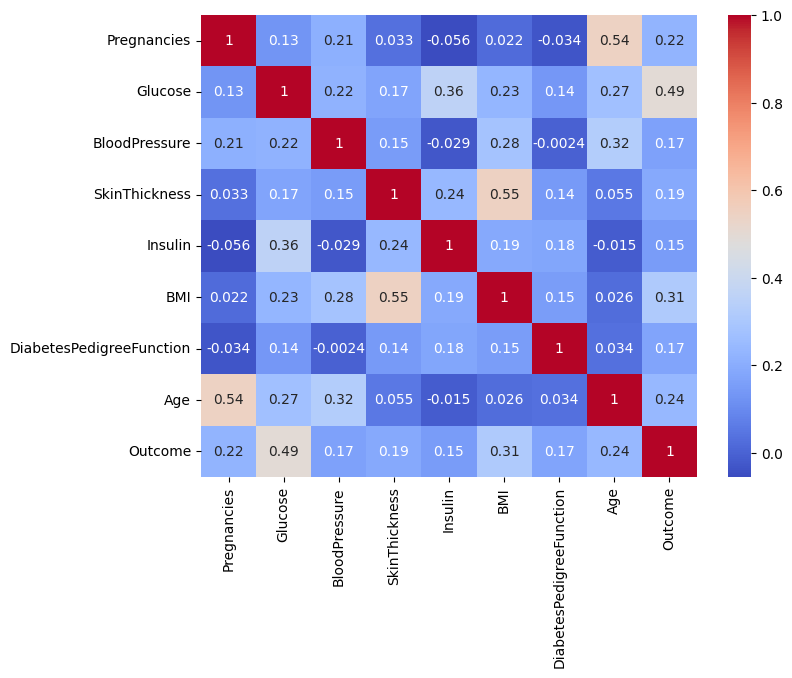

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()


In [35]:
X=data["Glucose"].values
X=( X-X.mean() ) / X.std()    # more scaled value of x so that model can predict easily not get bias for one catogory
y=data["Outcome"].values

In [36]:
print(X[:10])
print(y[:10])

[ 0.86604475 -1.20506583  2.01666174 -1.07356674  0.50442227 -0.18594792
 -1.43518922 -0.21882269  2.47690853  0.10992502]
[1 0 1 0 1 0 1 0 1 1]


## Defining Sigmoid Function

In [37]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("sigmoid test for z=0:" ,sigmoid(0))
print("sigmoid test for z=148:" ,sigmoid(1533))

sigmoid test for z=0: 0.5
sigmoid test for z=148: 1.0


## Initialize Parameters

In [38]:
m=0
c=0
lr=0.01
epochs=5000
n=len(y)
print(f"\nInitial weight (m): {m}")
print(f"Initial bias (c): {c}")


Initial weight (m): 0
Initial bias (c): 0


In [39]:
# 5. Training Loop (Gradient Descent)

for i in range(epochs):
    z=m*X+c
    y_pred=sigmoid(z)

    # Gradients
    dm = (1/n) * np.sum(X * (y_pred - y))
    dc = (1/n) * np.sum(y_pred - y)

    # Updating Parameters
    m = m - lr * dm
    c = c - lr * dc

    if i% (epochs//10)==0:
        loss = (-1/n) * np.sum(
            y * np.log(y_pred + 1e-9) +
            (1 - y) * np.log(1 - y_pred + 1e-9)
        )

        print("Epoch :",i)
        print("loss :",loss)
        print("Weight(m) :",m)
        print("Bias(c) :",c)
        print()

    

Epoch : 0
loss : 0.6931471785599453
Weight(m) : 0.002348801799494501
Bias(c) : -0.0015104166666666666

Epoch : 500
loss : 0.5436155711565753
Weight(m) : 0.6946007915623211
Bias(c) : -0.44487345342637635

Epoch : 1000
loss : 0.522899587214437
Weight(m) : 0.9603583149039127
Bias(c) : -0.6098777498876929

Epoch : 1500
loss : 0.5183839322380956
Weight(m) : 1.0868819364679034
Bias(c) : -0.6851179920240628

Epoch : 2000
loss : 0.5171901184827983
Weight(m) : 1.152799162042352
Bias(c) : -0.7228091367898948

Epoch : 2500
loss : 0.5168446012311675
Weight(m) : 1.1885888838143408
Bias(c) : -0.7426309556670688

Epoch : 3000
loss : 0.516739863708163
Weight(m) : 1.2084217626360179
Bias(c) : -0.7533470557813146

Epoch : 3500
loss : 0.516707318024324
Weight(m) : 1.219527938192758
Bias(c) : -0.7592372069241037

Epoch : 4000
loss : 0.5166970665348101
Weight(m) : 1.2257812584843804
Bias(c) : -0.7625082598643377

Epoch : 4500
loss : 0.5166938129459966
Weight(m) : 1.229312158321479
Bias(c) : -0.764336746441

## Final Model Evaluation

In [40]:
z_final=m * X + c   # because here we got the final value of m and c
probabilities=sigmoid(z_final)

print("Final Predictions : (first 10) ",probabilities[:10])

y_pred_class=np.where(probabilities>=0.5,1,0)

print("\nPredicted Classes (first 10):",y_pred_class[:10])

accuracy = np.mean(y_pred_class == y)
print("Accuracy",accuracy)

Final Predictions : (first 10)  [0.57468799 0.09542141 0.84784081 0.11034218 0.46399652 0.27005956
 0.07360973 0.26215472 0.90758267 0.34750819]

Predicted Classes (first 10): [1 0 1 0 0 0 0 0 1 0]
Accuracy 0.7447916666666666


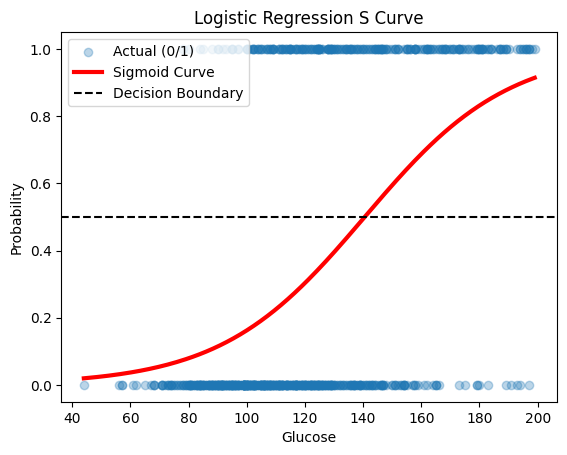

In [52]:
X_raw = data["Glucose"].values

# scale like training
mean, std = X_raw.mean(), X_raw.std()
X_scaled = (X_raw - mean)/std

# smooth curve
X_line = np.linspace(X_scaled.min(), X_scaled.max(), 200)
y_line = sigmoid(m*X_line + c)

# convert back
X_line = X_line*std + mean

# plot
plt.scatter(X_raw, y, alpha=0.3, label="Actual (0/1)")
plt.plot(X_line, y_line, color="red", linewidth=3, label="Sigmoid Curve")
plt.axhline(0.5, linestyle="--", color="black", label="Decision Boundary")

plt.xlabel("Glucose")
plt.ylabel("Probability")
plt.title("Logistic Regression S Curve")
plt.legend(loc="upper left")

plt.show()


# The sigmoid curve shows that as glucose levels increase, the probability of diabetes also increases. The model uses a 0.5 threshold to classify outcomes. Individuals with glucose levels above the decision boundary are more likely to be predicted as diabetic. This indicates that glucose level is an important feature for diabetes prediction.